# Importing required libraries

In [1]:
import requests
import json
import time

from pymongo import MongoClient

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Connecting to MongoDB (for storing the data)

In [2]:
client = MongoClient("mongodb://localhost:27017/")
db = client["BigData"]
collection = db["RadMon"]

### Sample API call:
https://data.epa.ie/radmon/api/v1/measurements?page=12&per_page=2

# API Call and Data Entry Pipeline
(commented as data is already inserted)

In [ ]:
# # Base API URL
# base_url = "https://data.epa.ie/radmon/api/v1/measurements"
# per_page = 200000  # max is usually better to reduce request count
# page = 1

# while True:
#     print(f"Fetching page {page}...")
#     response = requests.get(base_url, params={"page": page, "per_page": per_page})
    
#     if response.status_code != 200:
#         print(f"Error: Failed to fetch page {page} — status code {response.status_code}")
#         break

#     json_data = response.json()
    
#     # Look for data key
#     measurements = json_data.get("list", [])

#     if not measurements:
#         print("No more data to fetch.")
#         break  # Stop when no data returned
    
#     # Optional: prevent duplicate inserts (based on some unique key)
#     # For simplicity, assuming data is okay to insert as-is
#     collection.insert_many(measurements)
#     print(f"Inserted {len(measurements)} records from page {page}.")

#     page += 1
#     time.sleep(0.5)  # Be nice to the API (optional)

# if measurements:
#     print("Done fetching data.")


In [4]:
# print(response.status_code)
# print(response.json())

# Creating Spark session using PySpark for big data processing

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EPA Radiation Data") \
    .config("spark.jars", "./mongo-spark-connector_2.12-10.4.1-all.jar") \
    .config("spark.mongodb.read.connection.uri", "mongodb://localhost:27017/BigData.RadMon") \
    .config("spark.mongodb.write.connection.uri", "mongodb://localhost:27017/BigData.RadMon_output") \
    .getOrCreate()

In [4]:
print(spark.sparkContext._jsc.sc().listJars())

Vector(spark://UC:52290/jars/mongo-spark-connector_2.12-10.4.1-all.jar)


# Loading table into Spark

In [5]:
table = spark.read.format("mongodb").load()
table.show(5)

+--------------------+------------------+-------------------------+----------------------------+----------+--------------------+---------------------------+-------------------+--------+-----------+------------+------------+-----+--------+-------------------+-----------------+----------------+---------------+----------------------+-----------+------+---------------+--------------------+------------------+--------------------+------------+-----------------+-----------------+------------------+--------------------+-----------------+---------------------+-----------------+-------------+-------------------------+-------------------------+-------------+-----------------+-----------------+--------------+--------------------+------------------+----------------+------------+-------------------+-------------+-------------------+---------------------+----------------------------+----------------+-----------------------+-----------+------------------+-----------+-----------+---------------------+-

In [6]:
table.columns

['_id',
 'accuracy_type_code',
 'accuracy_type_description',
 'alternative_native_sample_id',
 'background',
 'background_unit_code',
 'background_unit_description',
 'begin_meas',
 'comments',
 'core_height',
 'country_code',
 'country_name',
 'depth',
 'dw_ratio',
 'end_meas',
 'height_above_land',
 'height_above_sea',
 'instrument_code',
 'instrument_description',
 'is_approved',
 'is_mda',
 'laboratory_code',
 'laboratory_name',
 'laboratory_section',
 'last_updated',
 'latitude_dec',
 'latitude_ig',
 'latitude_itm',
 'location_catchment',
 'location_code',
 'location_comments',
 'location_display_name',
 'location_name',
 'location_nuts',
 'location_third_party_code',
 'location_type_description',
 'longitude_dec',
 'longitude_ig',
 'longitude_itm',
 'measurement_id',
 'measurement_interval',
 'native_analysis_id',
 'native_sample_id',
 'nuclide_code',
 'nuclide_description',
 'result_number',
 'samp_time',
 'sample_treatment_code',
 'sample_treatment_description',
 'sample_type_c

# Selecting important columns for faster processing

In [7]:
important_columns = [
    'latitude_dec', 'longitude_dec', 'height_above_land', 'height_above_sea',
    'begin_meas', 'end_meas', 'samp_time',
    'value', 'value_unit_code', 'uncertainty', 'uncertainty_unit_code', 'result_number', 'is_mda',
    'nuclide_code', 'nuclide_description',
    'instrument_code', 'instrument_description',
    'country_name', 'location_name', 'location_type_description', 'source_name',
    'laboratory_name', 'laboratory_section',
    'is_approved', 'accuracy_type_code', 'accuracy_type_description'
]

table_selected = table.select(*important_columns)
table_selected.show(5)

+------------+-------------+-----------------+----------------+-------------------+-------------------+-------------------+----------+---------------+-----------+---------------------+-------------+------+------------+-------------------+---------------+----------------------+------------+-----------------+-------------------------+-----------+--------------------+------------------+-----------+------------------+-------------------------+
|latitude_dec|longitude_dec|height_above_land|height_above_sea|         begin_meas|           end_meas|          samp_time|     value|value_unit_code|uncertainty|uncertainty_unit_code|result_number|is_mda|nuclide_code|nuclide_description|instrument_code|instrument_description|country_name|    location_name|location_type_description|source_name|     laboratory_name|laboratory_section|is_approved|accuracy_type_code|accuracy_type_description|
+------------+-------------+-----------------+----------------+-------------------+-------------------+---------

# Aggregation operations

In [12]:
from pyspark.sql.functions import avg, count, max, min, stddev

table_selected.groupBy("location_name", "end_meas").agg(avg("value")).show()

+-----------------+-------------------+--------------------+
|    location_name|           end_meas|          avg(value)|
+-----------------+-------------------+--------------------+
|      Cahirciveen|2013-06-13T10:56:00|0.001018533333333...|
|        Glasnevin|2014-06-11T10:30:00|0.001407488000000...|
|           Dublin|2014-02-25T12:01:00|     33.281850248935|
|Belfield (Dublin)|2014-10-02T10:16:00|         0.001312505|
|      Cahirciveen|2015-01-08T10:08:00|          9.00184E-4|
|         Casement|2013-12-31T12:59:59|   40.22991307576497|
|      Cahirciveen|2013-12-31T05:59:59|   42.92595036824544|
|          Dundalk|2013-12-31T21:59:59|  53.733030954996735|
|         Casement|2014-01-01T18:59:59|   39.41416740417478|
|       Drogheda A|2014-01-01T22:59:59|  1.2945035833333334|
|       Clonskeagh|2014-01-02T17:59:59|   25.18783906215821|
|         Rosslare|2014-01-03T07:59:59|   40.78646151224772|
|         Rosslare|2014-01-03T17:59:59|  40.361122767130546|
|          Gurteen|2014-

In [13]:
table_selected.groupBy("location_name").agg(
    count("*").alias("total_measurements"),
    avg("value").alias("avg_value"),
    min("value").alias("min_value"),
    max("value").alias("max_value"),
    stddev("value").alias("stddev_value")
).show()

+--------------------+------------------+--------------------+--------------------+--------------------+--------------------+
|       location_name|total_measurements|           avg_value|           min_value|           max_value|        stddev_value|
+--------------------+------------------+--------------------+--------------------+--------------------+--------------------+
|             Gurteen|            181241|   38.71664968058291|             -0.1182|   146.7672983805339|  37.231854365453536|
|    Longford Central|                 2|              0.0432|              0.0155|              0.0709|0.039173715677734734|
|          Portlaoise|                 2|             0.05135|0.032799999999999996|              0.0699| 0.02623366158202092|
|           Sally Gap|                 1|               335.0|               335.0|               335.0|                null|
|               Howth|              1227|   8.402367008450776|              2.0E-7|               322.0|   28.17402445

In [ ]:
table.groupBy("value_unit_code").count().show()

+---------------+-------+
|value_unit_code|  count|
+---------------+-------+
|          NSV/H|3844491|
|          BQ/KG|   7241|
|           BQ/L|   3190|
|          BQ/M3|1442828|
|          BQ/M2|     24|
|           NONE|3899029|
|     X_BQ/KG-DW|   1741|
|           BQ_L|     87|
+---------------+-------+



In [17]:
table.select(["value_unit_code", "value_unit_description"]).distinct().show()

+---------------+----------------------+
|value_unit_code|value_unit_description|
+---------------+----------------------+
|          BQ/M3|  BECQUEREL PER CUB...|
|           NONE|         NOT SPECIFIED|
|          BQ/M2|  BECQUEREL PER SQU...|
|           BQ/L|   BECQUEREL PER LITRE|
|          NSV/H|  NANO-SIEVERT PER ...|
|          BQ/KG|  BECQUEREL PER KIL...|
|     X_BQ/KG-DW|  BECQUEREL PER KIL...|
|           BQ_L|                  null|
+---------------+----------------------+



# Creating a 1% sample of the dataset for EDA and Visualizations

In [22]:
df = table_selected.sample(fraction=0.01)
df.show()

+-----------------+-------------------+-----------------+----------------+-------------------+-------------------+-------------------+--------------------+---------------+--------------------+---------------------+-------------+------+------------+--------------------+---------------+----------------------+------------+-----------------+-------------------------+-----------+--------------------+------------------+-----------+------------------+-------------------------+
|     latitude_dec|      longitude_dec|height_above_land|height_above_sea|         begin_meas|           end_meas|          samp_time|               value|value_unit_code|         uncertainty|uncertainty_unit_code|result_number|is_mda|nuclide_code| nuclide_description|instrument_code|instrument_description|country_name|    location_name|location_type_description|source_name|     laboratory_name|laboratory_section|is_approved|accuracy_type_code|accuracy_type_description|
+-----------------+-------------------+-----------

# Performing EDA with Spark

In [26]:
from pyspark.sql.functions import col, isnan

df.filter(col("value").isNull() | isnan(col("value"))).count()

0

## Partitioning dataframe into two dataframes
(one where 'value' is measured in Becquerel per cubic metre and another where 'value' is measured in nanoSievert per hour)

In [ ]:
df_bq = df.filter(df['value_unit_code'].rlike('BQ'))
df_sv = df.filter(df['value_unit_code'].rlike('NSV/H'))

In [31]:
df_bq.show()

+-----------------+-------------------+-----------------+----------------+-------------------+-------------------+-------------------+--------------------+---------------+--------------------+---------------------+-------------+------+------------+--------------------+---------------+----------------------+------------+-----------------+-------------------------+-----------+--------------------+------------------+-----------+------------------+-------------------------+
|     latitude_dec|      longitude_dec|height_above_land|height_above_sea|         begin_meas|           end_meas|          samp_time|               value|value_unit_code|         uncertainty|uncertainty_unit_code|result_number|is_mda|nuclide_code| nuclide_description|instrument_code|instrument_description|country_name|    location_name|location_type_description|source_name|     laboratory_name|laboratory_section|is_approved|accuracy_type_code|accuracy_type_description|
+-----------------+-------------------+-----------

## Converting all types of Becquerel-based units into one (Bq/m3) for better analysis

In [ ]:
from pyspark.sql.functions import when, col, lit

df_bq = df_bq.withColumn(
    "value_bqm3",
    when(col("value_unit_code") == "BQ/M3", col("value"))
    .when(col("value_unit_code") == "BQ/L", col("value") * 1000)
    .when(col("value_unit_code") == "BQ_L", col("value") * 1000)
    .when(col("value_unit_code") == "BQ/KG", col("value") * lit(1200))       # Soil density
    .when(col("value_unit_code") == "X_BQ/KG-DW", col("value") * lit(400))   # Dry weight
    .when(col("value_unit_code") == "BQ/M2", col("value") / lit(0.05))       # Assumed depth of 5cm
    .otherwise(None)
)

df_bq.show()

+-----------------+-------------------+-----------------+----------------+-------------------+-------------------+-------------------+--------------------+---------------+--------------------+---------------------+-------------+------+------------+--------------------+---------------+----------------------+------------+-----------------+-------------------------+-----------+--------------------+------------------+-----------+------------------+-------------------------+--------------------+
|     latitude_dec|      longitude_dec|height_above_land|height_above_sea|         begin_meas|           end_meas|          samp_time|               value|value_unit_code|         uncertainty|uncertainty_unit_code|result_number|is_mda|nuclide_code| nuclide_description|instrument_code|instrument_description|country_name|    location_name|location_type_description|source_name|     laboratory_name|laboratory_section|is_approved|accuracy_type_code|accuracy_type_description|          value_bqm3|
+-------

In [32]:
df_sv.show()

+------------------+-------------------+-----------------+----------------+-------------------+-------------------+--------------------+------------------+---------------+-----------+---------------------+-------------+------+------------+-------------------+---------------+----------------------+------------+-------------+-------------------------+--------------------+--------------------+------------------+-----------+------------------+-------------------------+
|      latitude_dec|      longitude_dec|height_above_land|height_above_sea|         begin_meas|           end_meas|           samp_time|             value|value_unit_code|uncertainty|uncertainty_unit_code|result_number|is_mda|nuclide_code|nuclide_description|instrument_code|instrument_description|country_name|location_name|location_type_description|         source_name|     laboratory_name|laboratory_section|is_approved|accuracy_type_code|accuracy_type_description|
+------------------+-------------------+-----------------+--

In [52]:
df_bq.count(), df_sv.count()

(14611, 38191)

## Selecting a subset of both dataframes and converting them to Pandas dataframes

In [ ]:
pdf_bq = df_bq.select("end_meas", "value_bqm3", "value_unit_code", "nuclide_code", "longitude_dec", "latitude_dec").toPandas()
pdf_sv = df_sv.select("end_meas", "value", "value_unit_code", "nuclide_code", "longitude_dec", "latitude_dec").toPandas()

## EDA with Pandas

In [ ]:
pdf_bq = pdf_bq.dropna()
pdf_bq = pdf_bq.drop_duplicates()

pdf_sv = pdf_sv.dropna()
pdf_sv = pdf_sv.drop_duplicates()

pdf_bq.info()
pdf_sv.info()

## Data Visualization using Plots

### 1. Histograms

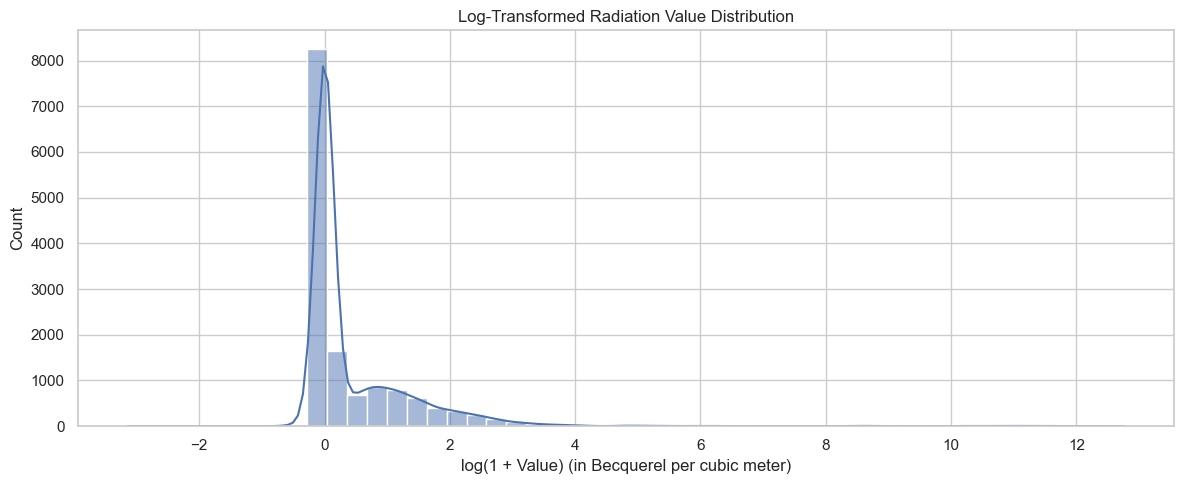

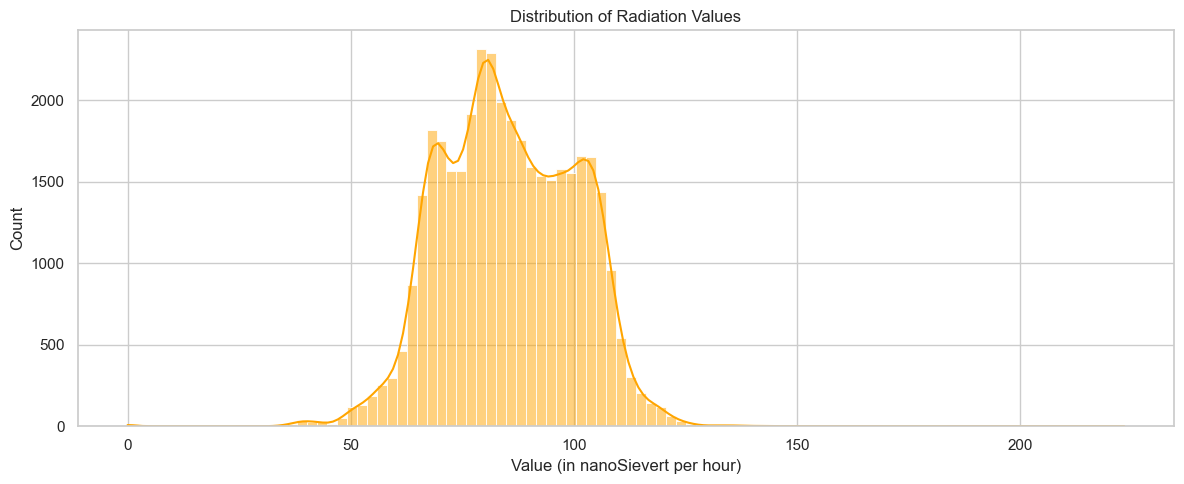

In [ ]:
pdf_bq['log_value_bqm3'] = np.log1p(pdf_bq['value_bqm3'])

plt.figure(figsize=(12, 5))
sns.histplot(data=pdf_bq, x='log_value_bqm3', bins=50, kde=True)
plt.title("Log-Transformed Radiation Value Distribution")
plt.xlabel("log(1 + Value) (in Becquerel per cubic meter)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(data=pdf_sv, x='value', bins=100, color='orange', kde=True)
plt.title("Distribution of Radiation Values")
plt.xlabel("Value (in nanoSievert per hour)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### 2. Line Charts for Time Series Analysis

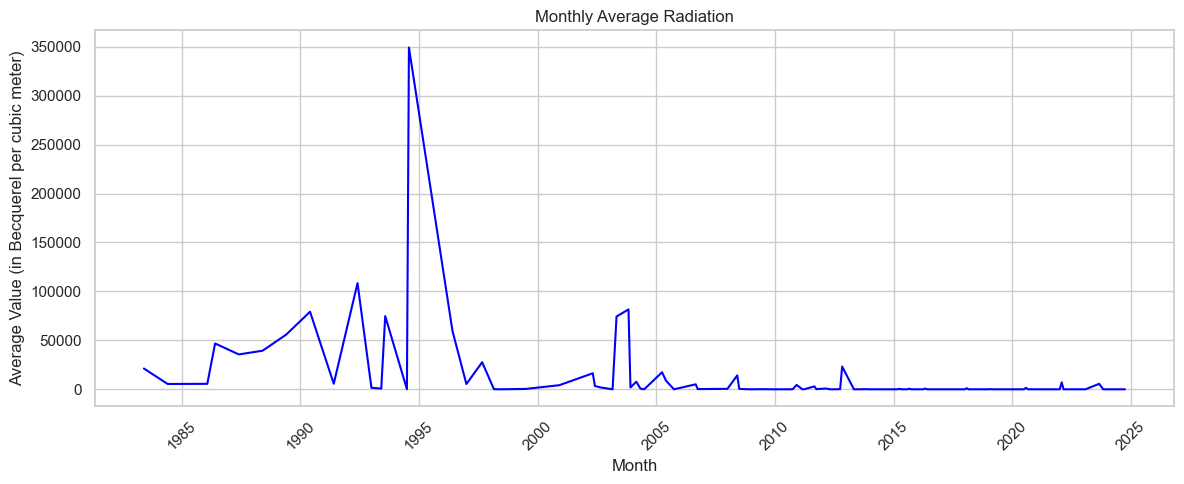

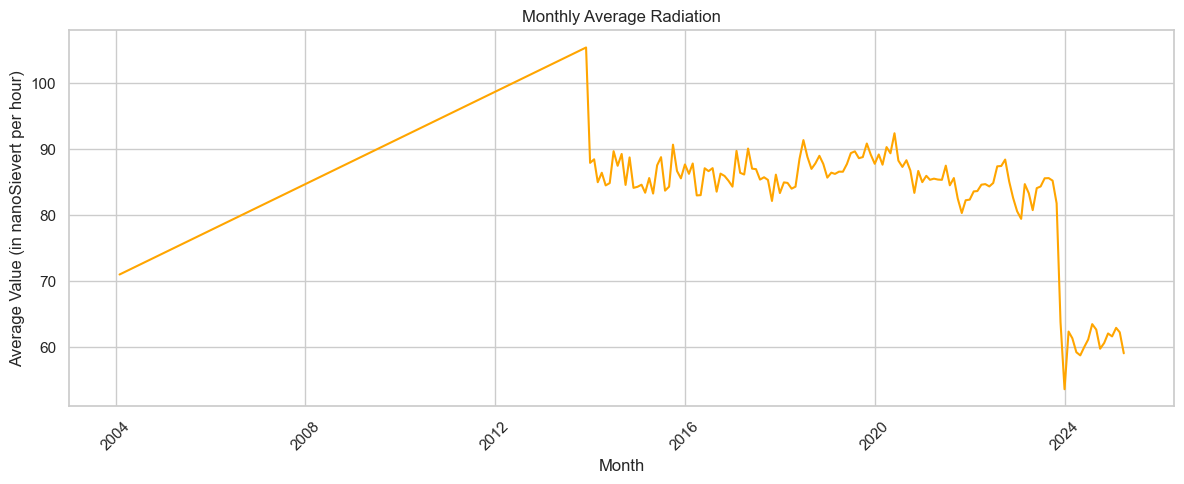

In [ ]:
pdf_bq['end_meas'] = pd.to_datetime(pdf_bq['end_meas'])
pdf_bq['month'] = pdf_bq['end_meas'].dt.to_period('M')
monthly_avg_bq = pdf_bq.groupby('month')['value_bqm3'].mean().reset_index()
monthly_avg_bq['month'] = monthly_avg_bq['month'].dt.to_timestamp()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_avg_bq, x='month', y='value_bqm3')
plt.title("Monthly Average Radiation")
plt.ylabel("Average Value (in Becquerel per cubic meter)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pdf_sv['end_meas'] = pd.to_datetime(pdf_sv['end_meas'])
pdf_sv['month'] = pdf_sv['end_meas'].dt.to_period('M')
monthly_avg_sv = pdf_sv.groupby('month')['value'].mean().reset_index()
monthly_avg_sv['month'] = monthly_avg_sv['month'].dt.to_timestamp()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_avg_sv, x='month', y='value', color='orange')
plt.title("Monthly Average Radiation")
plt.ylabel("Average Value (in nanoSievert per hour)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3. Scatter Plot for the combined Monthly Average Radiation

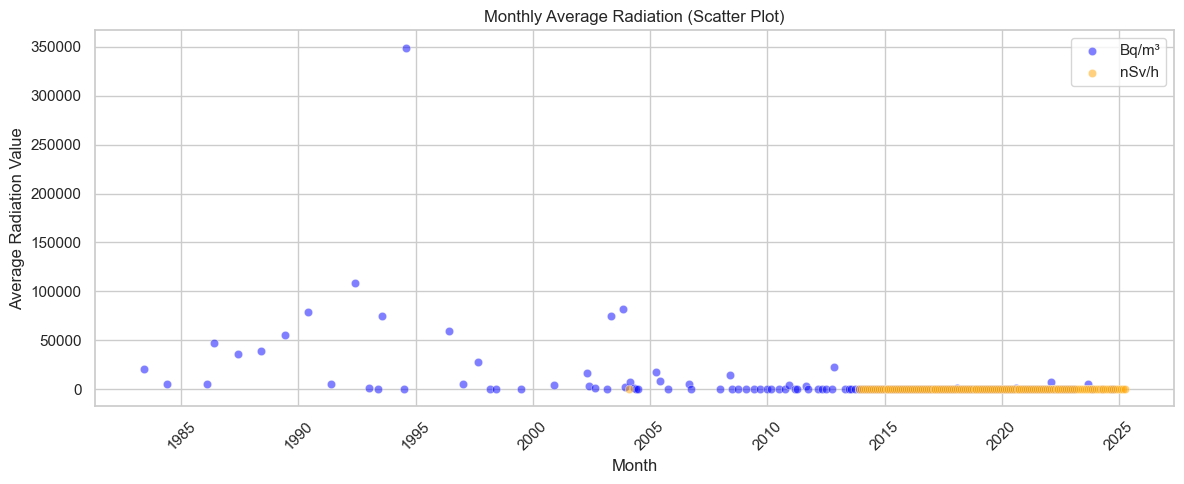

In [ ]:
plt.figure(figsize=(12, 5))

sns.scatterplot(data=monthly_avg_bq, x='month', y='value_bqm3', color='blue', label='Bq/m³', alpha=0.5)
sns.scatterplot(data=monthly_avg_sv, x='month', y='value', color='orange', label='nSv/h', alpha=0.5)

plt.title("Monthly Average Radiation (Scatter Plot)")
plt.ylabel("Average Radiation Value")
plt.xlabel("Month")
plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()
plt.show()

### 4. Geospatial Visualization using Folium HeatMaps

In [78]:
import folium
from folium.plugins import HeatMap

bq_map_center = [pdf_bq["latitude_dec"].mean(), pdf_bq["longitude_dec"].mean()]
m_bq = folium.Map(location=bq_map_center, zoom_start=4)
bq_heat_data = pdf_bq[["latitude_dec", "longitude_dec", "value_bqm3"]].values.tolist()
HeatMap(bq_heat_data, radius=8, blur=12, max_zoom=6).add_to(m_bq)

m_bq.save("bq_radiation_heatmap.html")

sv_map_center = [pdf_sv["latitude_dec"].mean(), pdf_sv["longitude_dec"].mean()]
m_sv = folium.Map(location=sv_map_center, zoom_start=4)
sv_heat_data = pdf_sv[["latitude_dec", "longitude_dec", "value"]].values.tolist()
HeatMap(sv_heat_data, radius=8, blur=12, max_zoom=6).add_to(m_sv)

m_sv.save("sv_radiation_heatmap.html")